# Limpieza y exploración de los datos 

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns   
import matplotlib.pyplot as plt

In [2]:
hs = pd.read_csv("../data/global_house_purchase_dataset.csv")
print(f"Dimensions of the dataset: {hs.shape}  ")
hs

Dimensions of the dataset: (200000, 25)  


,property_id,country,city,property_type,furnishing_status,property_size_sqft,price,constructed_year,previous_owners,rooms,...,customer_salary,loan_amount,loan_tenure_years,monthly_expenses,down_payment,emi_to_income_ratio,satisfaction_score,neighbourhood_rating,connectivity_score,decision
0,1,France,Marseille,Farmhouse,Semi-Furnished,991,412935,1989,6,6,...,10745,193949,15,6545,218986,0.16,1,5,6,0
1,2,South Africa,Cape Town,Apartment,Semi-Furnished,1244,224538,1990,4,8,...,16970,181465,20,8605,43073,0.08,9,1,2,0
2,3,South Africa,Johannesburg,Farmhouse,Semi-Furnished,4152,745104,2019,5,2,...,21914,307953,30,2510,437151,0.09,6,8,1,0
3,4,Germany,Frankfurt,Farmhouse,Semi-Furnished,3714,1110959,2008,1,3,...,17980,674720,15,8805,436239,0.33,2,6,6,0
4,5,South Africa,Johannesburg,Townhouse,Fully-Furnished,531,99041,2007,6,3,...,17676,65833,25,8965,33208,0.03,3,3,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,199996,Germany,Berlin,Villa,Fully-Furnished,685,203328,1968,1,3,...,78330,104050,15,17670,99278,0.01,8,4,5,1
199996,199997,China,Shenzhen,Townhouse,Unfurnished,3818,1454627,1977,5,7,...,25400,1175297,20,2865,279330,0.34,7,10,9,1
199997,199998,Japan,Kyoto,Villa,Semi-Furnished,3603,1619147,1990,2,4,...,28220,743049,30,5595,876098,0.17,5,3,9,0
199998,199999,South Africa,Johannesburg,Apartment,Unfurnished,1706,306165,2010,0,4,...,12240,150774,15,16300,155391,0.11,6,10,6,0


In [3]:
hs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 25 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   property_id              200000 non-null  int64  
 1   country                  200000 non-null  object 
 2   city                     200000 non-null  object 
 3   property_type            200000 non-null  object 
 4   furnishing_status        200000 non-null  object 
 5   property_size_sqft       200000 non-null  int64  
 6   price                    200000 non-null  int64  
 7   constructed_year         200000 non-null  int64  
 8   previous_owners          200000 non-null  int64  
 9   rooms                    200000 non-null  int64  
 10  bathrooms                200000 non-null  int64  
 11  garage                   200000 non-null  int64  
 12  garden                   200000 non-null  int64  
 13  crime_cases_reported     200000 non-null  int64  
 14  lega

In [4]:
# Valores nulos 
hs.isnull().sum()

property_id                0
country                    0
city                       0
property_type              0
furnishing_status          0
property_size_sqft         0
price                      0
constructed_year           0
previous_owners            0
rooms                      0
bathrooms                  0
garage                     0
garden                     0
crime_cases_reported       0
legal_cases_on_property    0
customer_salary            0
loan_amount                0
loan_tenure_years          0
monthly_expenses           0
down_payment               0
emi_to_income_ratio        0
satisfaction_score         0
neighbourhood_rating       0
connectivity_score         0
decision                   0
dtype: int64

In [5]:
#Valores duplicados
hs.duplicated().sum()

np.int64(0)

In [7]:
#Descripción estadística de las variables numéricas
hs.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
property_id,200000.0,NaN,NaN,NaN,100000.5,57735.171256,1.0,50000.75,100000.5,150000.25,200000.0
country,200000,13,France,15628,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,200000,40,Singapore,15278,NaN,NaN,NaN,NaN,NaN,NaN,NaN
property_type,200000,6,Farmhouse,33518,NaN,NaN,NaN,NaN,NaN,NaN,NaN
furnishing_status,200000,3,Fully-Furnished,66829,NaN,NaN,NaN,NaN,NaN,NaN,NaN
property_size_sqft,200000.0,NaN,NaN,NaN,3195.63346,1613.322287,400.0,1802.0,3190.0,4589.0,6000.0
price,200000.0,NaN,NaN,NaN,1215365.1275,823663.258915,56288.0,565989.5,1023429.0,1725556.5,4202732.0
constructed_year,200000.0,NaN,NaN,NaN,1991.48777,18.494064,1960.0,1975.0,1991.0,2008.0,2023.0
previous_owners,200000.0,NaN,NaN,NaN,3.00137,2.002198,0.0,1.0,3.0,5.0,6.0
rooms,200000.0,NaN,NaN,NaN,4.513855,2.295669,1.0,3.0,5.0,7.0,8.0


Conteo por clase:
decision
0    153932
1     46068
Name: count, dtype: int64

Porcentaje:
decision
0    76.97
1    23.03
Name: proportion, dtype: float64


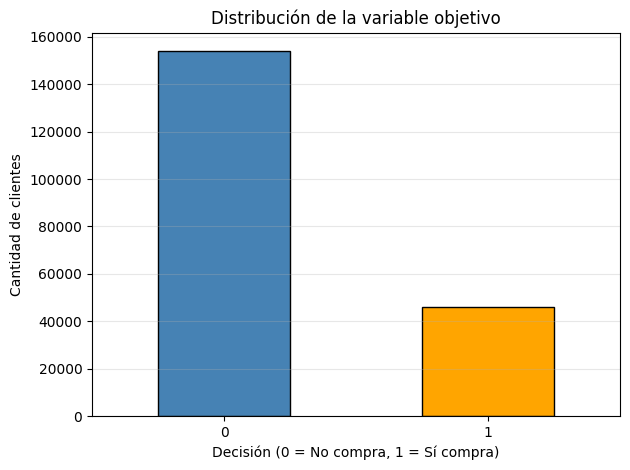

In [10]:
conteo = hs['decision'].value_counts()
porcentaje = hs['decision'].value_counts(normalize=True) * 100

print("Conteo por clase:")
print(conteo)
print("\nPorcentaje:")
print(porcentaje.round(2))

conteo.plot(kind='bar', color=['steelblue', 'orange'], edgecolor='black')
plt.title('Distribución de la variable objetivo')
plt.xlabel('Decisión (0 = No compra, 1 = Sí compra)')
plt.ylabel('Cantidad de clientes')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Vemos un desbalance en 0 y 1 quiza mayor de 70.97 % a 23.03%
- 0 No compra  y cuenta con aproximado de 150,000 registros
- 1 Si compra y cuenta con aproximado de 50,000 registros 


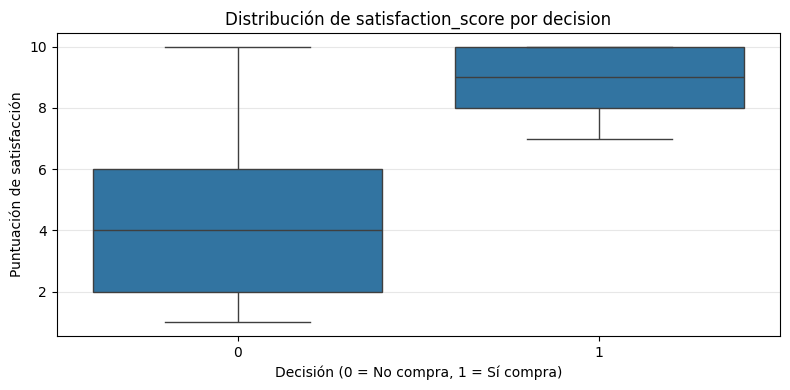

In [12]:
plt.figure(figsize=(8,4))
sns.boxplot(x="decision", y="satisfaction_score", data=hs)
plt.title("Distribución de satisfaction_score por decision")
plt.xlabel("Decisión (0 = No compra, 1 = Sí compra)")
plt.ylabel("Puntuación de satisfacción")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

El boxplot muestra algo raro:
- Los que **NO compran** tienen `satisfaction_score` bajo (2–6).
- Los que **SÍ compran** tienen puntuaciones altas (8–10).

El cliente califica su satisfacción DESPUÉS de decidir comprar,
no antes, incluirlo al modelo estaría
aprendiendo la respuesta, no el comportamiento.

Por esta razón se excluye del modelado.


In [15]:
# Lista de columnas que son texto
# No caracteristica predictiva
# Satisfaction_score es descartada por ser la variable objetivo
drop_cols = ["property_id", "satisfaction_score"] 
cat_cols = ["country", "city", "property_type", "furnishing_status"]
num_cols = [col for col in hs.columns if col not in cat_cols + drop_cols + ["decision"]]
print(f"Columnas categóricas: {cat_cols}")
print(f"Columnas numéricas: {num_cols}")

Columnas categóricas: ['country', 'city', 'property_type', 'furnishing_status']
Columnas numéricas: ['property_size_sqft', 'price', 'constructed_year', 'previous_owners', 'rooms', 'bathrooms', 'garage', 'garden', 'crime_cases_reported', 'legal_cases_on_property', 'customer_salary', 'loan_amount', 'loan_tenure_years', 'monthly_expenses', 'down_payment', 'emi_to_income_ratio', 'neighbourhood_rating', 'connectivity_score']


Se excluyen property_id (no es predictor) y satisfaction_score (Fuga de Datos).

In [16]:
# Estadísticas descriptivas por clase
hs.groupby("decision")[num_cols].agg(["mean", "median", "std"])

property_size_sqft                              price             \
                       mean  median          std          mean     median   
decision                                                                    
0               3246.145636  3272.0  1616.006347  1.233212e+06  1033278.5   
1               3026.851654  2931.0  1592.761394  1.155732e+06   989078.5   

                        constructed_year                    previous_owners  \
                    std             mean  median        std            mean   
decision                                                                      
0         836704.507768      1991.519294  1991.0  18.491163        2.999467   
1         775539.760698      1991.382435  1991.0  18.503564        3.007728   

          ...   down_payment emi_to_income_ratio                   \
          ...            std                mean median       std   
decision  ...                                                       
0         ...  366005.618987            0.214140   0.13  0.242151   
1         ...  352438.722469            0.132727   0.11  0.092183   

         neighbourhood_rating                  connectivity_score         \
                         mean median       std               mean median   
decision                                                                   
0                    5.499792    5.0  2.870191           5.495141    5.0   
1                    5.523444    6.0  2.873418           5.497200    5.0   

                    
               std  
decision            
0         2.867984  
1         2.877649  

[2 rows x 54 columns]

Anteriormente tuve fuga de datos: satisfaction_score muestra separación casi perfecta,
indica que el score es consecuencia de la decisión, no predictor de ella.
Se EXCLUYE del modelado.

Las variables con mayor diferencia de medias entre clases son
crime_cases_reported, legal_cases_on_property y emi_to_income_ratio.
Son los mejores predictores reales del dataset.

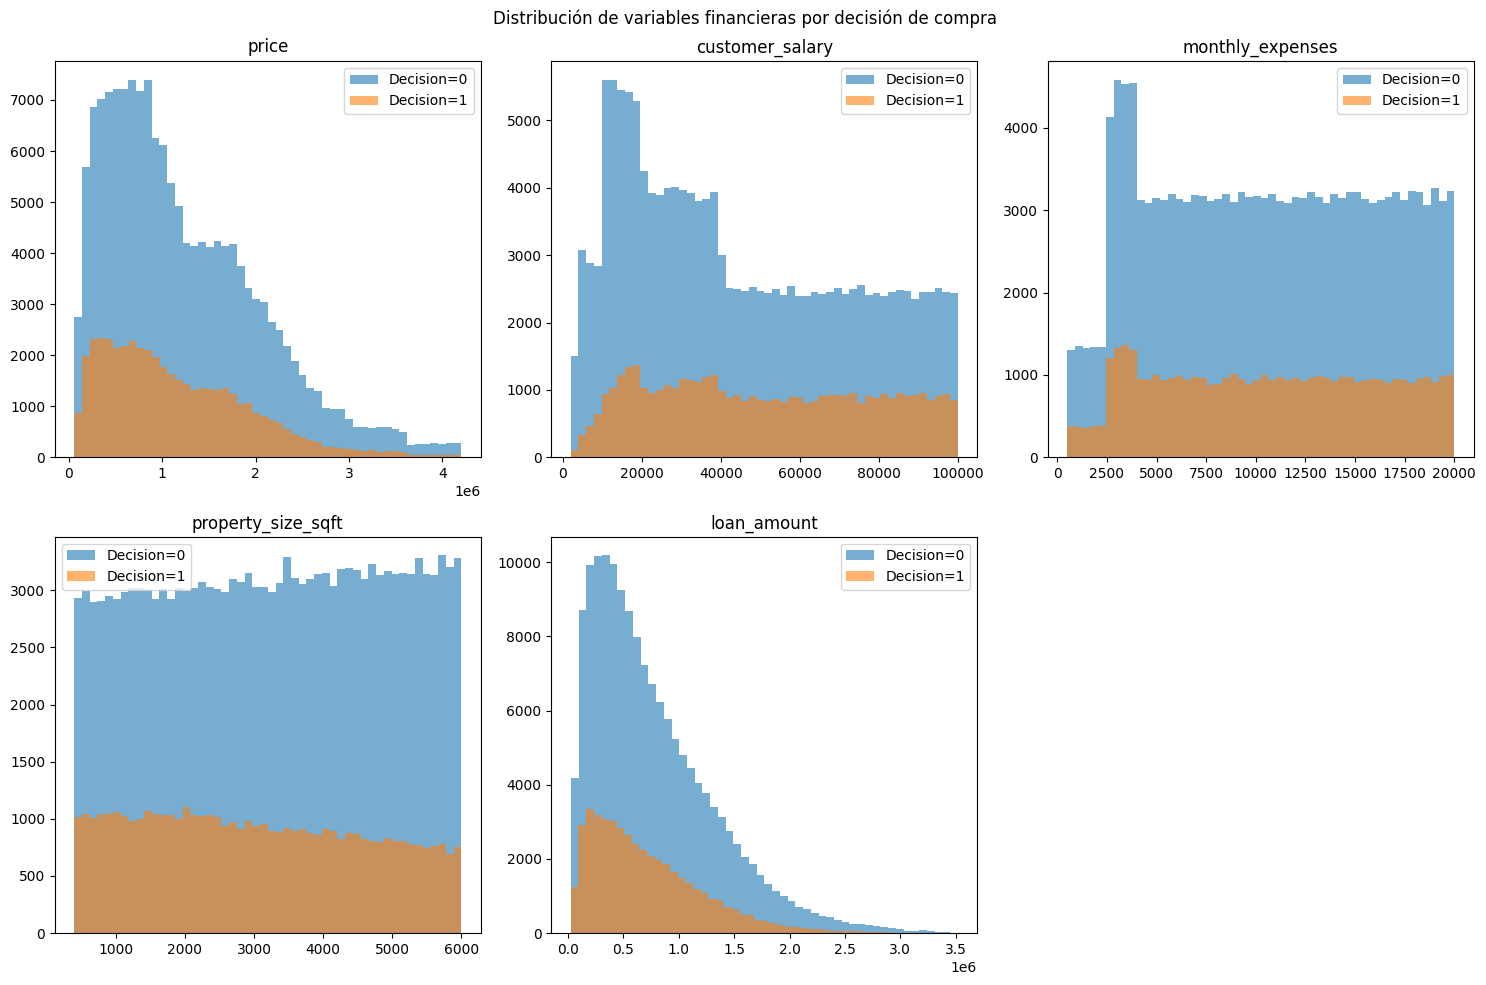

In [20]:
cols_to_plot = ["price", "customer_salary", "monthly_expenses", "property_size_sqft", "loan_amount"]
fig, axes = plt.subplots(2,3, figsize=(15,10))
axes = axes.flatten()
for i, col in enumerate(cols_to_plot):
    for dec in [0,1]:
        axes[i].hist(hs[hs["decision"]==dec][col], bins=50, alpha=0.6, label=f"Decision={dec}")
    axes[i].set_title(col)
    axes[i].legend()
axes[5].set_visible(False)
plt.suptitle("Distribución de variables financieras por decisión de compra")
plt.tight_layout()
plt.show()

Distribuciones muy sesgadas, debera trabajarse al entrenar la red.

Para que los modelos no se dejen engañar por unos pocos valores gigantes, aplicaremos 
una transformación logarítmica: `log(price)`, `log(salary)`, etc.

Además, las curvas de compradores y no compradores casi se superponen: **ninguna 
variable por sí sola separa las clases**. Por eso en la siguiente fase crearemos 
ratios como `affordability_ratio = log(salary) – log(price)`

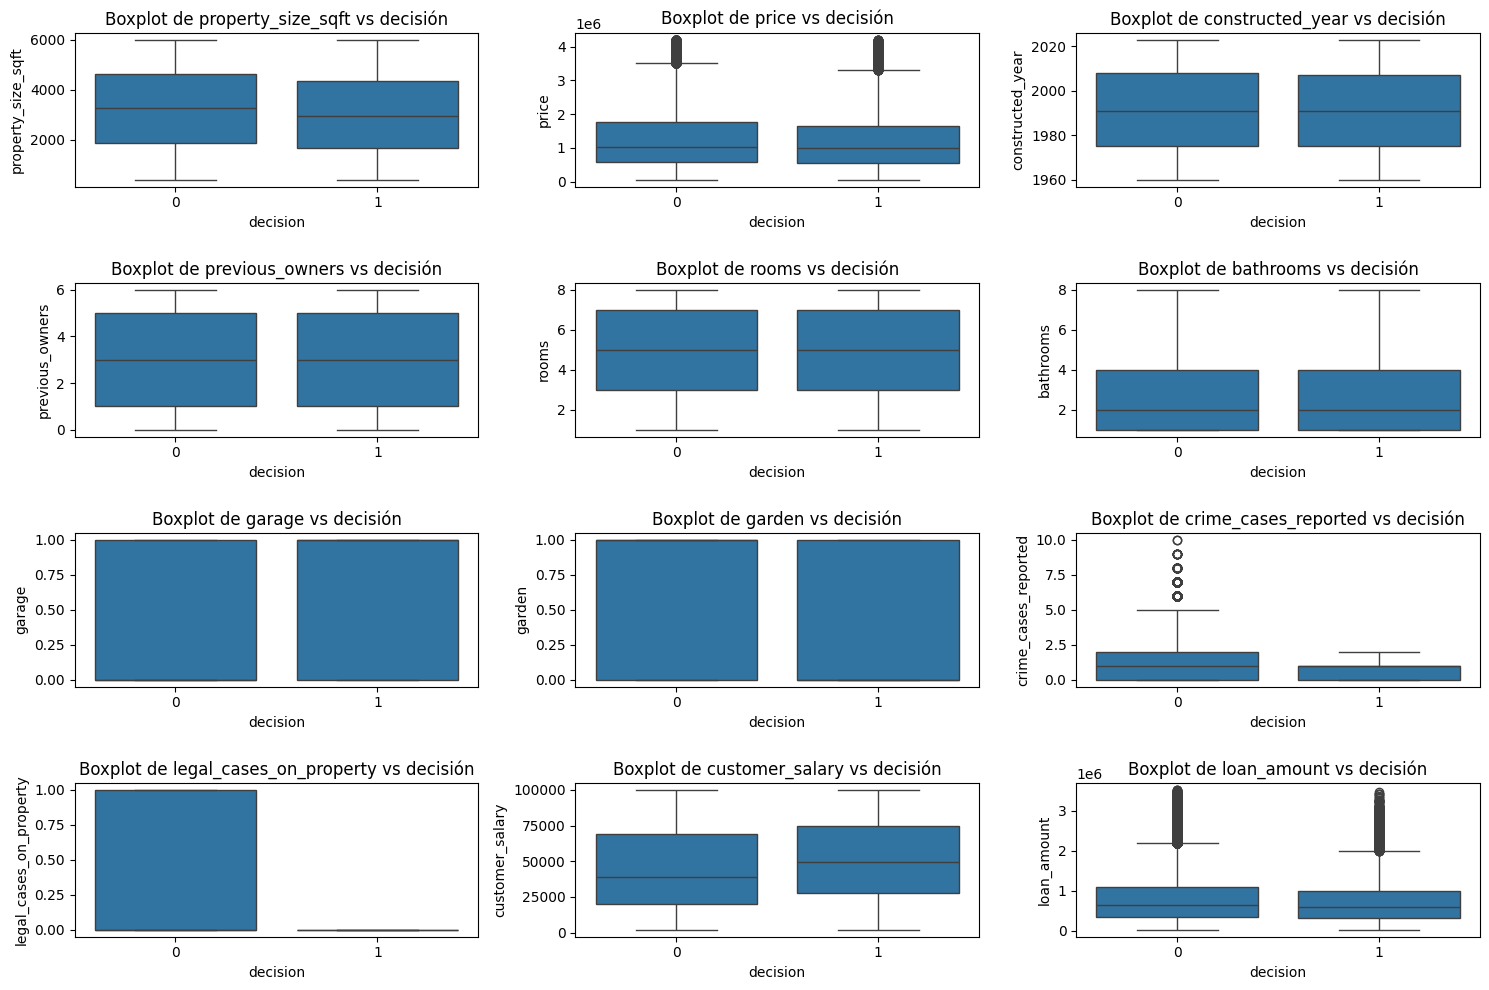

In [23]:
plt.figure(figsize=(15,10))
for i, col in enumerate(num_cols[:12]):
    plt.subplot(4,3,i+1)
    sns.boxplot(x="decision", y=col, data=hs)
    plt.title(f"Boxplot de {col} vs decisión")
plt.tight_layout()
plt.show()


Podemos ver que hay outliers y diferencias de la mediana.
- crime_cases_reported y legal_cases_on_property sí separan compradores 
  de no compradores — son buenos predictores.
- El resto de variables tienen distribuciones casi iguales entre clases.
- price y loan_amount tienen outliers extremos — se aplicará log en procesamiento.
```

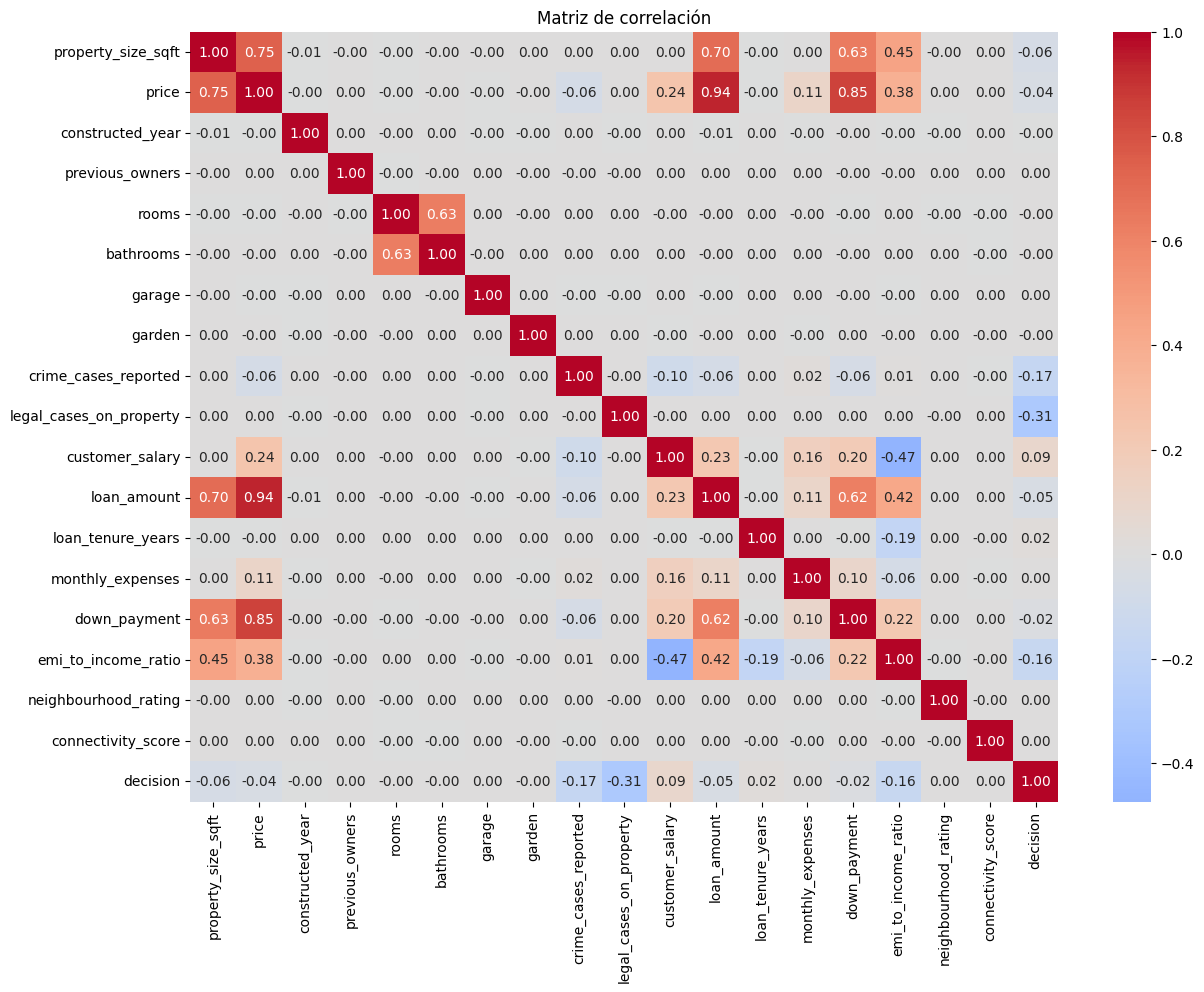

In [13]:
plt.figure(figsize=(14,10))
corr = hs[num_cols + ["decision"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlación")
plt.show()


Con satisfaction_score ya excluida, las correlaciones con decision son bajas:

- legal_cases_on_property: -0.31 (la más fuerte — más problemas legales, menos compras)
- crime_cases_reported: -0.17
- emi_to_income_ratio: -0.16

Esto significa que ninguna variable por sí sola predice bien la decisión.
El modelo necesitará combinarlas para encontrar patrones.

También se observa que price, loan_amount y down_payment están muy 
correlacionadas entre sí (0.85 - 0.94), lo cual es esperado porque 
todas describen el costo de la propiedad.

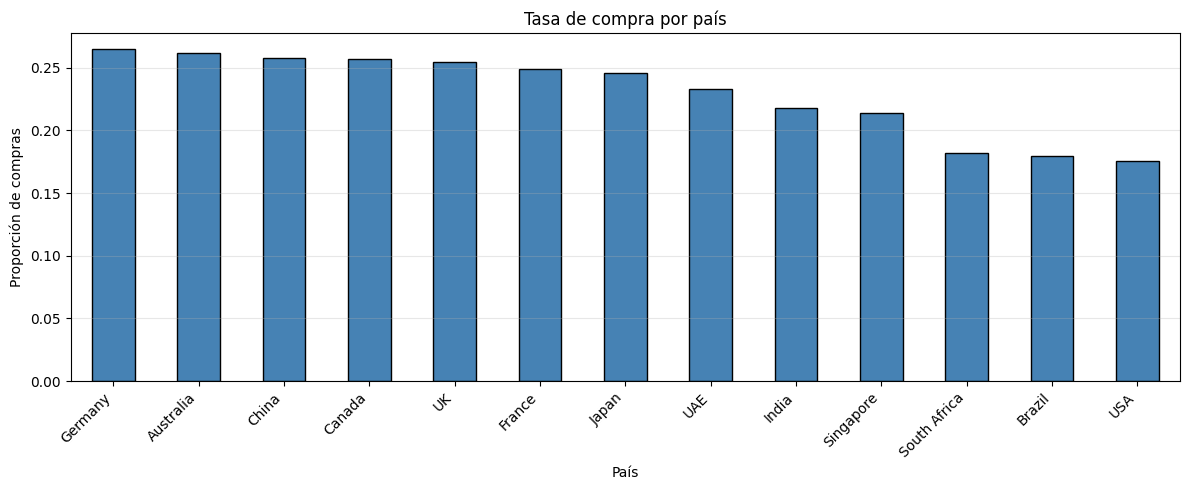

In [25]:
tasa_pais = hs.groupby("country")["decision"].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
tasa_pais.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Tasa de compra por país")
plt.xlabel("País")
plt.ylabel("Proporción de compras")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

La tasa de compra varía por país: Alemania lidera con ~22%, mientras que
la mayoría de países oscila alrededor del 20% de media global.
Esto confirma que country es un predictor geográfico relevante, aunque
con diferencias moderadas entre regiones.

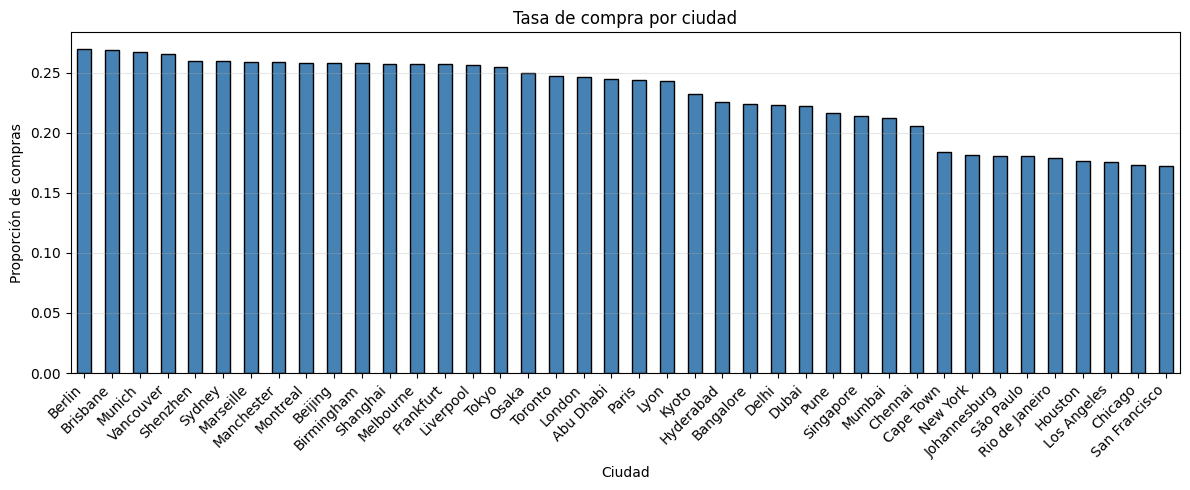

In [27]:
tasa_ciudad = hs.groupby("city")["decision"].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 5))
tasa_ciudad.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Tasa de compra por ciudad")
plt.xlabel("Ciudad")
plt.ylabel("Proporción de compras")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Algunas ciudades tienen tasas de compra notablemente más altas.
City tiene alta cardinalidad (muchas categorías) por lo que
el One-Hot Encoding generará varias columnas — esto es esperado.

Variables predictoras prometedoras (satisfaction_score EXCLUIDA por fuga de datos):

- crime_cases_reported: menos crimen correlaciona con mayor intención de compra
- legal_cases_on_property: propiedades sin problemas legales se compran más
- emi_to_income_ratio: ratio controlado es condición de compra
- country/city: la ubicación tiene valor predictivo moderado (~22% vs ~18%)
- price, customer_salary, monthly_expenses: útiles como ratios derivados
  (affordability_ratio, expense_burden), no como valores crudos
